In [1]:

!pip install -q -U transformers accelerate peft bitsandbytes datasets
!pip install -q -U qwen-vl-utils
!pip install -q -U matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 102.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 45.2 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.6 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dep

Resolving data files:   0%|          | 0/16467 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Total samples: 14236
Columns: ['image', 'label']


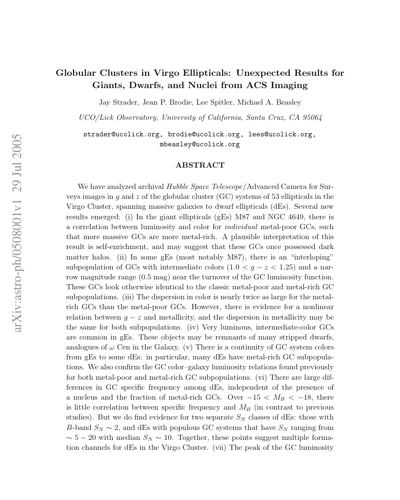

Ground Truth Snippet:
 0

Training samples: 11388
Validation samples: 2848


In [2]:
import os
import torch
from datasets import load_dataset, Dataset
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"

# Load the dataset
try:
    dataset = load_dataset(dataset_path, split="train")
except:
    # Fallback if it's a generic folder
    dataset = load_dataset("imagefolder", data_dir=dataset_path, split="train")

print(f"Total samples: {len(dataset)}")
print(f"Columns: {dataset.column_names}")

sample = dataset[0]
display(sample["image"].resize((400, 500))) 

# Automatically detect the text column (whichever column is NOT 'image')
text_col_name = [col for col in dataset.column_names if col != 'image'][0]

print("Ground Truth Snippet:\n", str(sample[text_col_name])[:200]) 

# Split into 80/20 train/validation
split_dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset['train']
eval_dataset = split_dataset['test']

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(eval_dataset)}")

In [3]:
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_id = "Qwen/Qwen2-VL-2B-Instruct"

# Configure 4-bit Quantization (T4 GPUs optimize best with fp16)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load Processor (Limit image resolution to save VRAM on T4: 512-768px)
# max_pixels = 768 * 768 limits the visual token sequence length
processor = AutoProcessor.from_pretrained(model_id, max_pixels=768*768)

# Load Base Model
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto", # Automatically distributes across the 2x T4 GPUs
    torch_dtype=torch.float16
)

# Prepare for QLoRA
model = prepare_model_for_kbit_training(model)

# Define LoRA Adapters
peft_config = LoraConfig(
    r=16, # LoRA rank 16 as requested
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


In [4]:
class Qwen2VLDataCollator:
    def __init__(self, processor):
        self.processor = processor
        self.system_prompt = "Convert the following document image into structured Markdown text."

    def __call__(self, examples):
        texts = []
        images = []
        
        for ex in examples:
            # ChatML format expected by Qwen2-VL
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": ex["image"]},
                        {"type": "text", "text": self.system_prompt}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [
                        {"type": "text", "text": ex["label"]} 
                    ]
                }
            ]
            
            # Apply chat template
            text = self.processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )
            texts.append(text)
            images.append(ex["image"])

        # Process the batch
        batch = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True
        )
        
        # Create labels for standard Causal LM training
        labels = batch["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        batch["labels"] = labels
        
        return batch

data_collator = Qwen2VLDataCollator(processor)

In [ ]:
# Training Arguments configured for Kaggle T4x2
training_args = TrainingArguments(
    output_dir="./qwen-nougat-qlora-output",
    per_device_train_batch_size=1,      # 1 per GPU
    gradient_accumulation_steps=8,      # Effective batch size = 1 * 2(GPUs) * 8 = 16
    per_device_eval_batch_size=1,
    num_train_epochs=3,                 # Recommended 2-5
    learning_rate=2e-4,                 # Using 2e-4 for QLoRA
    fp16=True,                          # T4 optimized
    save_strategy="epoch",
    eval_strategy="epoch",              # Fixed argument name
    logging_steps=10,
    optim="paged_adamw_8bit",           # Memory efficient optimizer
    remove_unused_columns=False,        # CRITICAL: Must be False for multimodal data
    report_to="none"                    # Disable wandb to prevent login prompt
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

# Clear cache before starting
torch.cuda.empty_cache()

# Execute Fine-Tuning
trainer.train()

# Save final adapter weights
trainer.save_model("./qwen-nougat-final-adapter")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current itera

Epoch,Training Loss,Validation Loss


In [ ]:
def generate_markdown(image, instruction_prompt):
    model.eval()
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": instruction_prompt}
            ]
        }
    ]
    
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True).to("cuda")
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=512)
        
    # Trim the prompt from the generated output
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    
    return output_text

In [ ]:
def visualize_results(dataset_split, num_samples=3, title="Results"):
    instruction = "Convert the following document image into structured Markdown text."
    
    for i in range(num_samples):
        sample = dataset_split[i]
        image = sample["image"]
        ground_truth = sample["markdown"]
        
        # Generate prediction
        prediction = generate_markdown(image, instruction)
        
        # Display Results visually
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f"{title} - Sample {i+1}", fontsize=16, fontweight='bold')
        
        # Show Image
        axes[0].imshow(image)
        axes[0].axis('off')
        axes[0].set_title("Input Document Image")
        
        # Show Text Comparison
        axes[1].axis('off')
        comparison_text = f"--- GROUND TRUTH ---\n{ground_truth[:400]}...\n\n" \
                          f"--- PREDICTION ---\n{prediction[:400]}..."
        axes[1].text(0, 0.5, comparison_text, fontsize=10, verticalalignment='center', wrap=True)
        axes[1].set_title("Markdown Comparison (Truncated)")
        
        plt.tight_layout()
        plt.show()
        
        print(f"Full Prediction for Sample {i+1}:\n{prediction}\n")
        print("="*80)

# 1. Test on 3 Training Images
print("TESTING ON TRAINING IMAGES")
visualize_results(train_dataset, num_samples=3, title="Training Data Evaluation")

# 2. Test on 3 Unseen Validation Images
print("TESTING ON UNSEEN VALIDATION IMAGES")
visualize_results(eval_dataset, num_samples=3, title="Unseen Data Evaluation")